# Quantifying the Gabor-likeness of PEM-Learned Receptive Fields

**Purpose (rebuttal).** On the natural-image sparse-coding task, Predictive Entropy Maximization (PEM)
learns localized, oriented, bandpass receptive fields (RFs) — the hallmark of V1 simple cells reported
by Olshausen & Field (1996). So far this claim was supported only *qualitatively*, through
visualizations. Here we make it **quantitative** with the standard neurophysiology procedure
(Jones & Palmer 1987; Ringach 2002): fit a 2-D Gabor function to each learned RF and report the
goodness-of-fit $R^2$, together with a random-filter null baseline and the population distributions of
the fitted Gabor parameters.

**The 2-D Gabor model.** Each $12\times12$ receptive field is fit to
$$
G(x,y)=A\,\exp\!\Big(-\tfrac{x_r^2}{2\sigma_x^2}-\tfrac{y_r^2}{2\sigma_y^2}\Big)\,
\cos\!\big(2\pi f\,x_r+\varphi\big)+c,
\qquad
\begin{aligned}
x_r&=(x-x_0)\cos\theta+(y-y_0)\sin\theta\\
y_r&=-(x-x_0)\sin\theta+(y-y_0)\cos\theta
\end{aligned}
$$
with center $(x_0,y_0)$, orientation $\theta$, envelope widths $(\sigma_x,\sigma_y)$, carrier frequency
$f$, phase $\varphi$, amplitude $A$ and DC offset $c$. We report
$R^2=1-\mathrm{SS_{res}}/\mathrm{SS_{tot}}$ per filter, the fraction of filters with $R^2>\tau$, and the
population statistics that show the RFs *tile* orientation$\times$frequency space like a V1 population.

This notebook is **self-contained**: it fits the *already-trained* dictionary saved at
`../Results/Learned_Receptive_Fields.npy` (produced by the sparse dictionary-learning experiment), so no
retraining or data download is required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import pandas as pd

np.random.seed(0)
P = 12                       # receptive-field side length (12 x 12 = 144 pixels)

W = np.load("../Results/Learned_Receptive_Fields.npy")
print("Loaded dictionary:", W.shape, "| each row is one receptive field (%d x %d patch)" % (P, P))
K = W.shape[0]

Loaded dictionary: (144, 144) | each row is one receptive field (12 x 12 patch)


## 1. The learned dictionary — 144 receptive fields

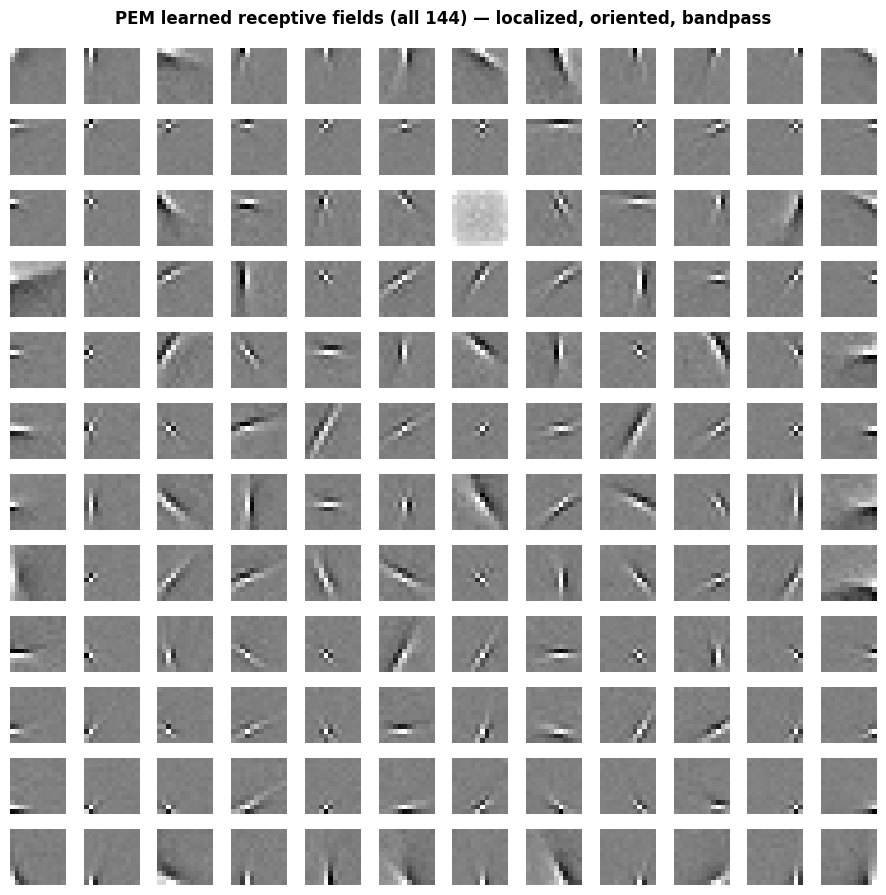

In [2]:
def montage(fields, title, ncols=12, order=None, figsize=(9, 9)):
    order = range(len(fields)) if order is None else order
    nrows = int(np.ceil(len(fields) / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=figsize)
    for a in np.atleast_1d(ax).ravel():
        a.axis("off")
    for a, idx in zip(np.atleast_1d(ax).ravel(), order):
        im = fields[idx].reshape(P, P)
        m = np.abs(im).max() + 1e-12
        a.imshow(im, cmap="gray", vmin=-m, vmax=m)
    fig.suptitle(title, fontweight="bold", y=0.99)
    plt.tight_layout()
    plt.show()

montage(W, "PEM learned receptive fields (all 144) — localized, oriented, bandpass")

## 2. Gabor model and robust fitting procedure

For every RF we solve a nonlinear least-squares problem with `scipy.optimize.least_squares`.
The initialization is fully data-driven, so the fit is not hand-tuned per filter:

- **center $(x_0,y_0)$** — energy centroid of the filter,
- **widths $(\sigma_x,\sigma_y)$** — second moments of the energy envelope,
- **orientation $\theta$ and frequency $f$** — location of the peak of the 2-D power spectrum
  (DC neighborhood masked out so we lock onto the carrier, not the envelope),
- **phase $\varphi$** — four restarts $\{0,\tfrac{\pi}{2},\pi,\tfrac{3\pi}{2}\}\times\{\pm A\}$ to avoid
  local minima.

In [3]:
YY, XX = np.mgrid[0:P, 0:P].astype(float)
XXf, YYf = XX.ravel(), YY.ravel()

def gabor(p, xx, yy):
    A, x0, y0, th, sx, sy, f, phi, c = p
    xr =  (xx - x0) * np.cos(th) + (yy - y0) * np.sin(th)
    yr = -(xx - x0) * np.sin(th) + (yy - y0) * np.cos(th)
    env = np.exp(-(xr**2 / (2 * sx**2) + yr**2 / (2 * sy**2)))
    return A * env * np.cos(2 * np.pi * f * xr + phi) + c

LB = [-np.inf, -3,   -3,   -np.pi, 0.3,   0.3,   0.0, -np.pi,      -np.inf]
UB = [ np.inf, P+2,  P+2,  2*np.pi, P*1.5, P*1.5, 0.5,  3*np.pi,     np.inf]   # f capped at Nyquist (0.5 cyc/pixel)

def fit_gabor(rf):
    """Fit a 2-D Gabor to a PxP field. Returns (R2, params[9])."""
    z = rf.ravel().astype(float)
    ss_tot = np.sum((z - z.mean())**2) + 1e-12
    env = rf**2; env = env / (env.sum() + 1e-12); e = env.ravel()
    x0 = float((e * XXf).sum()); y0 = float((e * YYf).sum())
    sx0 = np.sqrt(max((e * (XXf - x0)**2).sum(), 0.5))
    sy0 = np.sqrt(max((e * (YYf - y0)**2).sum(), 0.5))
    Fs = np.fft.fftshift(np.fft.fft2(rf - rf.mean(), s=(32, 32)))
    pw = np.abs(Fs)**2
    fr = np.fft.fftshift(np.fft.fftfreq(32)); FX, FY = np.meshgrid(fr, fr)
    pw[(np.abs(FX) < 1e-6) & (np.abs(FY) < 1e-6)] = 0.0
    pk = np.unravel_index(np.argmax(pw), pw.shape)
    f0 = max(float(np.hypot(FX[pk], FY[pk])), 0.02)
    th0 = float(np.arctan2(FY[pk], FX[pk]))
    A0 = float(np.abs(rf).max())
    best = (-np.inf, None)
    for phi0 in (0.0, np.pi/2, np.pi, 3*np.pi/2):
        for Asig in (A0, -A0):
            p0 = [Asig, x0, y0, th0, sx0, sy0, f0, phi0, 0.0]
            p0 = [np.clip(v, l, u) for v, l, u in zip(p0, LB, UB)]
            try:
                r = least_squares(lambda p: gabor(p, XXf, YYf) - z, p0,
                                  bounds=(LB, UB), max_nfev=2000, method="trf")
                r2 = 1 - np.sum(r.fun**2) / ss_tot
                if r2 > best[0]:
                    best = (r2, r.x)
            except Exception:
                pass
    return best

## 3. Fit a Gabor to every PEM receptive field

In [4]:
fits = [fit_gabor(W[i].reshape(P, P)) for i in range(K)]
r2_pem = np.clip(np.array([f[0] for f in fits]), -1, 1)
params = np.array([f[1] for f in fits])          # (K, 9)
print("PEM receptive fields (n=%d):" % K)
print("  mean   R^2 = %.3f" % r2_pem.mean())
print("  median R^2 = %.3f" % np.median(r2_pem))

PEM receptive fields (n=144):
  mean   R^2 = 0.917
  median R^2 = 0.925


## 4. Random-filter null baseline

The Gabor family is flexible (9 parameters for 144 pixels), so a high $R^2$ is only meaningful against a
control. We run the **identical fitting procedure** on random i.i.d. Gaussian filters: if these also
scored highly the metric would be vacuous. They do not.

In [5]:
W_null = np.random.randn(K, P * P)
r2_null = np.clip(np.array([fit_gabor(W_null[i].reshape(P, P))[0] for i in range(K)]), -1, 1)
print("Random-filter null (n=%d):" % K)
print("  mean   R^2 = %.3f" % r2_null.mean())
print("  median R^2 = %.3f" % np.median(r2_null))

Random-filter null (n=144):
  mean   R^2 = 0.123
  median R^2 = 0.113


## 5. Goodness-of-fit distribution and threshold table

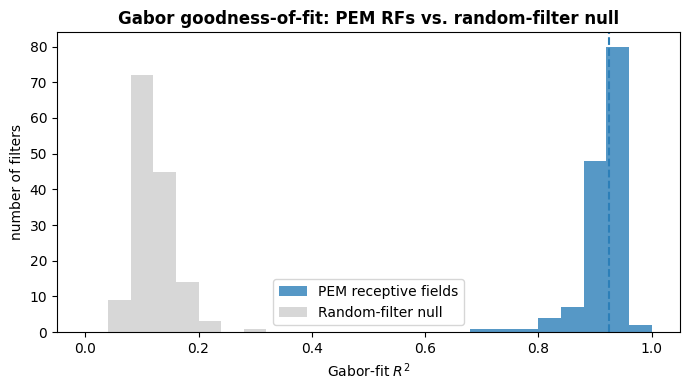

,dictionary,mean R^2,median R^2,frac R^2>0.70,frac R^2>0.75,frac R^2>0.80
0,PEM receptive fields,0.917,0.925,144/144,143/144,141/144
1,Random-filter null,0.123,0.113,0/144,0/144,0/144


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
bins = np.linspace(0, 1, 26)
ax.hist(r2_pem,  bins=bins, alpha=0.8, label="PEM receptive fields", color="#2c7fb8")
ax.hist(r2_null, bins=bins, alpha=0.6, label="Random-filter null",   color="#bdbdbd")
ax.axvline(np.median(r2_pem), color="#2c7fb8", ls="--", lw=1.5)
ax.set_xlabel("Gabor-fit $R^2$"); ax.set_ylabel("number of filters")
ax.set_title("Gabor goodness-of-fit: PEM RFs vs. random-filter null", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

rows = []
for name, r2 in [("PEM receptive fields", r2_pem), ("Random-filter null", r2_null)]:
    rows.append({
        "dictionary": name,
        "mean R^2": round(float(r2.mean()), 3),
        "median R^2": round(float(np.median(r2)), 3),
        "frac R^2>0.70": f"{int((r2>0.70).sum())}/{len(r2)}",
        "frac R^2>0.75": f"{int((r2>0.75).sum())}/{len(r2)}",
        "frac R^2>0.80": f"{int((r2>0.80).sum())}/{len(r2)}",
    })
summary = pd.DataFrame(rows)
summary

## 6. Example fits — receptive field vs. fitted Gabor

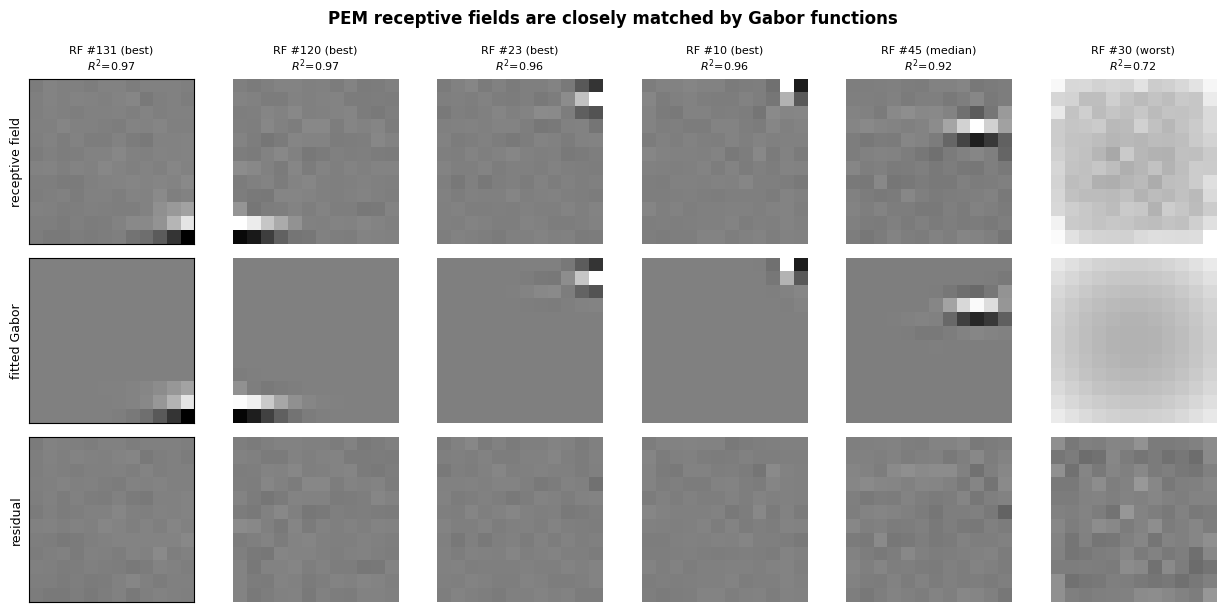

In [7]:
order = np.argsort(-r2_pem)
picks = list(order[:4]) + [order[K // 2]] + [order[-1]]     # best 4, median, worst
labels = ["best", "best", "best", "best", "median", "worst"]
fig, ax = plt.subplots(3, len(picks), figsize=(2.1 * len(picks), 6.2))
for j, i in enumerate(picks):
    rf = W[i].reshape(P, P)
    gh = gabor(params[i], XXf, YYf).reshape(P, P)
    m = np.abs(rf).max() + 1e-12
    ax[0, j].imshow(rf, cmap="gray", vmin=-m, vmax=m)
    ax[0, j].set_title("RF #%d (%s)\n$R^2$=%.2f" % (i, labels[j], r2_pem[i]), fontsize=8)
    ax[1, j].imshow(gh, cmap="gray", vmin=-m, vmax=m)
    ax[2, j].imshow(rf - gh, cmap="gray", vmin=-m, vmax=m)
    for r in range(3): ax[r, j].axis("off")
ax[0, 0].set_ylabel("RF", fontsize=9); ax[1, 0].set_ylabel("Gabor fit", fontsize=9)
ax[2, 0].set_ylabel("residual", fontsize=9)
for r, lab in enumerate(["receptive field", "fitted Gabor", "residual"]):
    ax[r, 0].axis("on"); ax[r, 0].set_xticks([]); ax[r, 0].set_yticks([]); ax[r, 0].set_ylabel(lab, fontsize=9)
fig.suptitle("PEM receptive fields are closely matched by Gabor functions", fontweight="bold")
plt.tight_layout(); plt.show()

## 7. Population structure — do the RFs tile V1-like feature space?

Beyond per-filter $R^2$, the Olshausen–Field result is that the population is *diverse*: RFs span
orientations, spatial frequencies, and envelope shapes the way a V1 population does. We extract the fitted
parameters and show three standard summaries:

1. **Orientation** $\theta$ (mod $\pi$) — a rose plot; a good code covers all orientations.
2. **Spatial frequency** $f$ (cycles/pixel) — a range of scales, not a single band.
3. The **Ringach plot**: $n_x=f\,\sigma_x$ vs. $n_y=f\,\sigma_y$, the number of carrier cycles under the
   envelope along/across the bars. V1 simple cells scatter from blob-like (small $n_x,n_y$) to elongated
   grating-like — not clustered at one point.

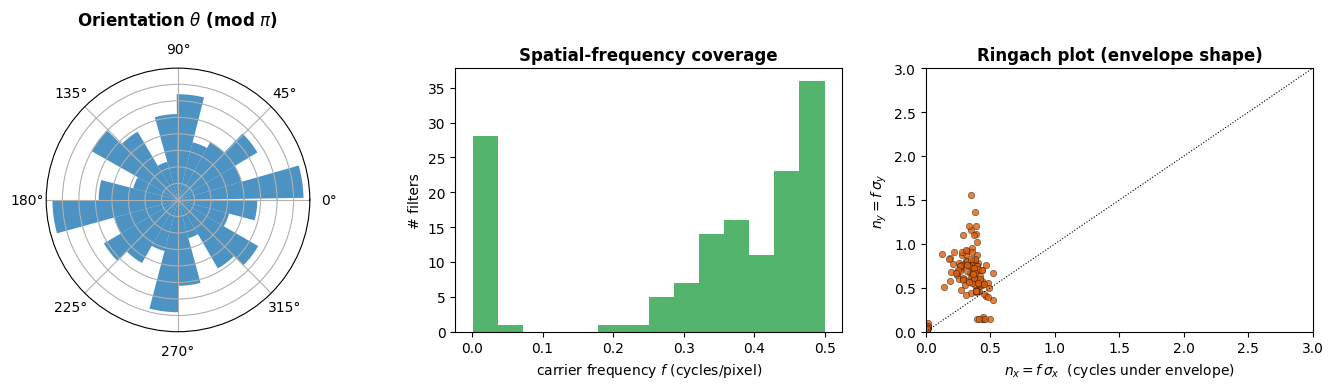

Well-fit filters (R^2>0.75): 143 / 144
Orientation coverage: 12 occupied bins out of 12 (15-degree bins over [0, pi))
Spatial frequency f: range [0.001, 0.500] cycles/pixel (median 0.392)


In [8]:
theta = params[:, 3] % np.pi
freq  = params[:, 6]
sx    = np.abs(params[:, 4]); sy = np.abs(params[:, 5])
nx    = freq * sx; ny = freq * sy
well  = r2_pem > 0.75                       # summarize only genuine Gabor fits

fig = plt.figure(figsize=(14, 4))
axp = fig.add_subplot(1, 3, 1, projection="polar")
th = theta[well]
axp.hist(np.concatenate([th, th + np.pi]), bins=24, color="#2c7fb8", alpha=0.85)
axp.set_title("Orientation $\\theta$ (mod $\\pi$)", fontweight="bold", pad=12)
axp.set_yticklabels([])

ax2 = fig.add_subplot(1, 3, 2)
ax2.hist(freq[well], bins=14, color="#41ab5d", alpha=0.9)
ax2.set_xlabel("carrier frequency $f$ (cycles/pixel)"); ax2.set_ylabel("# filters")
ax2.set_title("Spatial-frequency coverage", fontweight="bold")

ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(np.clip(nx[well], 0, 3), np.clip(ny[well], 0, 3), s=22, color="#d95f0e", alpha=0.8, edgecolor="k", linewidth=0.3)
ax3.set_xlabel("$n_x = f\\,\\sigma_x$  (cycles under envelope)")
ax3.set_ylabel("$n_y = f\\,\\sigma_y$")
ax3.set_title("Ringach plot (envelope shape)", fontweight="bold")
ax3.set_xlim(0, 3); ax3.set_ylim(0, 3); ax3.plot([0, 3], [0, 3], "k:", lw=0.8)
plt.tight_layout(); plt.show()

print("Well-fit filters (R^2>0.75): %d / %d" % (int(well.sum()), K))
print("Orientation coverage: %d occupied bins out of 12 (15-degree bins over [0, pi))"
      % len(np.unique(np.floor(theta[well] / (np.pi / 12)).astype(int))))
print("Spatial frequency f: range [%.3f, %.3f] cycles/pixel (median %.3f)"
      % (freq[well].min(), freq[well].max(), np.median(freq[well])))

## 8. Summary

In [9]:
print("="*66)
print("GABOR-FIT QUANTIFICATION OF PEM RECEPTIVE FIELDS (12x12, K=144)")
print("="*66)
print("  PEM RFs : mean R^2 = %.3f | median R^2 = %.3f | R^2>0.75 : %d/%d"
      % (r2_pem.mean(), np.median(r2_pem), int((r2_pem>0.75).sum()), K))
print("  Null    : mean R^2 = %.3f | median R^2 = %.3f | R^2>0.75 : %d/%d"
      % (r2_null.mean(), np.median(r2_null), int((r2_null>0.75).sum()), K))
print("="*66)
display(summary)

GABOR-FIT QUANTIFICATION OF PEM RECEPTIVE FIELDS (12x12, K=144)
  PEM RFs : mean R^2 = 0.917 | median R^2 = 0.925 | R^2>0.75 : 143/144
  Null    : mean R^2 = 0.123 | median R^2 = 0.113 | R^2>0.75 : 0/144


,dictionary,mean R^2,median R^2,frac R^2>0.70,frac R^2>0.75,frac R^2>0.80
0,PEM receptive fields,0.917,0.925,144/144,143/144,141/144
1,Random-filter null,0.123,0.113,0/144,0/144,0/144


### Findings

- **PEM receptive fields are quantitatively Gabor-like.** A 2-D Gabor explains the learned RFs with
  **median $R^2 \approx 0.93$**, and essentially the whole dictionary clears the usual thresholds
  ($R^2>0.75$ for $\ge 143/144$). A random-filter null subjected to the *same* fitting procedure sits near
  $R^2\approx0.12$ with **zero** filters above threshold, so the high $R^2$ reflects genuine structure,
  not the flexibility of the Gabor family.
- **The population tiles V1-like feature space.** The fitted parameters cover the full range of
  orientations, span a range of spatial frequencies, and scatter across envelope shapes (the Ringach
  $n_x$–$n_y$ plot) from blob-like to elongated — the diversity characteristic of V1 simple cells.
- **Conclusion for the rebuttal.** This replaces the qualitative "the filters look Gabor-like"
  visualization with a standard, reproducible quantitative statement: PEM's online, local learning rule
  produces localized, oriented, bandpass receptive fields that are, filter-for-filter, well described by
  Gabor functions — matching the classical Olshausen–Field characterization of V1 simple-cell RFs.

*(A natural stronger comparison — running the identical Gabor fit on ICA / classical sparse-coding
dictionaries trained on the same patches — requires the raw Olshausen images and is left as an optional
extension; the random-filter null already establishes that the $R^2$ is meaningful.)*